In [1]:
print('hello')

hello


In [2]:
import pandas as pd 
import numpy as np
import pickle


Carga de los datasets

In [3]:
datos = dict()
for i in range(1,7):
    nombre_archivo = f"../Simulaciones/sim_{i}_data.pkl"

    with open(nombre_archivo, 'rb') as f:
        datos_recuperados = pickle.load(f)
    datos[i]=datos_recuperados
    print(type(datos_recuperados),len(datos_recuperados))

<class 'dict'> 20
<class 'dict'> 20
<class 'dict'> 20
<class 'dict'> 20
<class 'dict'> 20
<class 'dict'> 20


Remuestreo

In [4]:
from Funciones import remuestrear
datos_prueba = {'t_min': list(range(1,16)),
    'valores': [0, 10, 0, 0, 20, 0, 0, 30, 0, 0, 0, 40, 0,1,3]
}
df_prueba = pd.DataFrame(datos_prueba)

print("DataFrame Original:")
print(df_prueba)

salida = remuestrear(df_prueba, ['t_min', 'valores'], 5)
print("\nDataFrame con los valores desplazados:")
print(salida)

DataFrame Original:
    t_min  valores
0       1        0
1       2       10
2       3        0
3       4        0
4       5       20
5       6        0
6       7        0
7       8       30
8       9        0
9      10        0
10     11        0
11     12       40
12     13        0
13     14        1
14     15        3

DataFrame con los valores desplazados:
    t_min  valores
0       6       10
5      30       50
10     55       40
15     44        5


In [5]:
datos.keys()

dict_keys([1, 2, 3, 4, 5, 6])

In [6]:
remuestrear(datos[3]['p_0'],columnas = ['meal_carb', 'snack_carb',
                                                     'bolus_insulin', 'basal_insulin'],
                                         t_muestreo=5)

,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0.0,6.000000,108.0,0.0,0.0,0.0,30.013287,0.0
5,5.0,6.000000,108.0,0.0,0.0,0.0,0.000000,0.0
10,10.0,6.000000,108.0,0.0,0.0,0.0,0.000000,0.0
15,15.0,5.999987,108.0,0.0,0.0,0.0,0.000000,0.0
20,20.0,5.999729,108.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...
43180,43180.0,9.728406,175.0,0.0,0.0,0.0,0.000000,0.0
43185,43185.0,9.669671,174.0,0.0,0.0,0.0,0.000000,0.0
43190,43190.0,9.610650,173.0,0.0,0.0,0.0,0.000000,0.0
43195,43195.0,9.551680,172.0,0.0,0.0,0.0,0.000000,0.0


In [ ]:
for s in range(1,7):
    for p in range(20):
        print(f'p{p}')
        datos[s][f'p_{p}'] = remuestrear(datos[i][f'p_{p}'],
                                         columnas = ['meal_carb', 'snack_carb','bolus_insulin', 'basal_insulin'],
                                         t_muestreo=5)

p0
p1
p2
p3
p4
p5
p6
p7
p8
p9
p10
p11
p12
p13
p14
p15
p16
p17
p18
p19
p0
p1
p2
p3
p4
p5
p6
p7
p8
p9
p10
p11
p12
p13
p14
p15
p16
p17
p18
p19
p0
p1
p2
p3
p4
p5
p6
p7
p8
p9
p10
p11
p12
p13
p14
p15
p16
p17
p18
p19
p0
p1
p2
p3
p4
p5
p6
p7
p8
p9
p10
p11
p12
p13
p14
p15
p16
p17
p18
p19


Escalado y Estandarizado

In [7]:
from Funciones import escalar,estandarizar

display(datos[3]['p_0'].head())
display(escalar(datos[3]['p_0']).head())
estandarizar(datos[3]['p_0']).head()

,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0,6.0,108.0,0.0,0.0,0.0,30.013287,0.0
1,1,6.0,108.0,0.0,0.0,0.0,0.000000,0.0
2,2,6.0,108.0,0.0,0.0,0.0,0.000000,0.0
3,3,6.0,108.0,0.0,0.0,0.0,0.000000,0.0
4,4,6.0,108.0,0.0,0.0,0.0,0.000000,0.0


,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0,0.001242,0.0,0.0,0.0,0.0,1.0,0.0
1,1,0.001242,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0.001242,0.0,0.0,0.0,0.0,0.0,0.0
3,3,0.001242,0.0,0.0,0.0,0.0,0.0,0.0
4,4,0.001242,0.0,0.0,0.0,0.0,0.0,0.0


,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0,-3.932365,-3.932794,-0.044534,-0.03728,-0.044534,37.934153,-0.145131
1,1,-3.932365,-3.932794,-0.044534,-0.03728,-0.044534,-0.026361,-0.145131
2,2,-3.932365,-3.932794,-0.044534,-0.03728,-0.044534,-0.026361,-0.145131
3,3,-3.932365,-3.932794,-0.044534,-0.03728,-0.044534,-0.026361,-0.145131
4,4,-3.932365,-3.932794,-0.044534,-0.03728,-0.044534,-0.026361,-0.145131


In [8]:
datos[3]['p_0']['gluc_mg'].min()

108.0

### Históricos

In [9]:
datos[1]['p_0'][datos[1]['p_0']['meal_carb']>0]

,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
503,503,5.993833,108.0,43.377778,0.0,1.845863,0.0,0.0
859,859,7.669420,138.0,75.530303,0.0,3.214055,0.0,0.0
1264,1264,8.367740,151.0,56.058586,0.0,2.385472,0.0,0.0
1961,1961,7.767855,140.0,46.088889,0.0,1.961229,0.0,0.0
2296,2296,9.092663,164.0,81.360606,0.0,3.462153,0.0,0.0
...,...,...,...,...,...,...,...,...
41190,41190,9.590798,173.0,76.396970,0.0,3.250935,0.0,0.0
41590,41590,9.513112,171.0,53.852525,0.0,2.291597,0.0,0.0
42285,42285,8.559010,154.0,44.488889,0.0,1.893144,0.0,0.0
42635,42635,9.523104,171.0,79.312121,0.0,3.374984,0.0,0.0


In [10]:
df_prueba = remuestrear(datos[1]['p_0'], columnas = ['meal_carb', 'snack_carb','bolus_insulin', 'basal_insulin'], t_muestreo=5)
print(datos[1]['p_0'].shape)
print(df_prueba.shape)

(43200, 8)
(8641, 8)


In [11]:
display(datos[1]['p_0'].tail(10))
df_prueba.tail(10)


,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
43190,43190,10.043879,181.0,0.0,0.0,0.0,0.0,0.0
43191,43191,10.032601,181.0,0.0,0.0,0.0,0.0,0.0
43192,43192,10.021263,180.0,0.0,0.0,0.0,0.0,0.0
43193,43193,10.009869,180.0,0.0,0.0,0.0,0.0,0.0
43194,43194,9.998422,180.0,0.0,0.0,0.0,0.0,0.0
43195,43195,9.986927,180.0,0.0,0.0,0.0,0.0,0.0
43196,43196,9.975387,180.0,0.0,0.0,0.0,0.0,0.0
43197,43197,9.963806,179.0,0.0,0.0,0.0,0.0,0.0
43198,43198,9.952187,179.0,0.0,0.0,0.0,0.0,0.0
43199,43199,9.940533,179.0,0.0,0.0,0.0,0.0,0.0


,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
43155,43155.0,10.365333,187.0,0.0,0.0,0.0,0.0,0.0
43160,43160.0,10.332157,186.0,0.0,0.0,0.0,0.0,0.0
43165,43165.0,10.293552,185.0,0.0,0.0,0.0,0.0,0.0
43170,43170.0,10.250270,185.0,0.0,0.0,0.0,0.0,0.0
43175,43175.0,10.203020,184.0,0.0,0.0,0.0,0.0,0.0
43180,43180.0,10.152469,183.0,0.0,0.0,0.0,0.0,0.0
43185,43185.0,10.099232,182.0,0.0,0.0,0.0,0.0,0.0
43190,43190.0,10.043879,181.0,0.0,0.0,0.0,0.0,0.0
43195,43195.0,9.986927,180.0,0.0,0.0,0.0,0.0,0.0
43200,43200.0,9.952187,179.0,0.0,0.0,0.0,0.0,0.0


In [12]:
display(df_prueba.head())
df_prueba = df_prueba.drop('glu_mmol', axis=1)
df_prueba.head()

,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0.0,6.000000,108.0,0.0,0.0,0.0,30.013287,0.0
5,5.0,6.000000,108.0,0.0,0.0,0.0,0.000000,0.0
10,10.0,6.000000,108.0,0.0,0.0,0.0,0.000000,0.0
15,15.0,5.999987,108.0,0.0,0.0,0.0,0.000000,0.0
20,20.0,5.999729,108.0,0.0,0.0,0.0,0.000000,0.0


,t_min,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0.0,108.0,0.0,0.0,0.0,30.013287,0.0
5,5.0,108.0,0.0,0.0,0.0,0.000000,0.0
10,10.0,108.0,0.0,0.0,0.0,0.000000,0.0
15,15.0,108.0,0.0,0.0,0.0,0.000000,0.0
20,20.0,108.0,0.0,0.0,0.0,0.000000,0.0


In [13]:
df_prueba['basal_-24h'] = df_prueba['basal_insulin'].rolling(window=287, closed='left', min_periods = 0).sum()

for col in ['meal_carb', 'snack_carb', 'bolus_insulin', 'running_speed']:

    df_prueba[f'{col}_-20m'] = df_prueba[col].rolling(window=4, closed='left').sum()
    df_prueba[f'{col}_-40m'] = df_prueba[col].rolling(window=8, closed='left').sum() - df_prueba[col].rolling(window=4, closed='left').sum()
    df_prueba[f'{col}_-60m'] = df_prueba[col].rolling(window=12, closed='left').sum() - df_prueba[col].rolling(window=8, closed='left').sum()
    df_prueba[f'{col}_-80m'] = df_prueba[col].rolling(window=16, closed='left').sum() - df_prueba[col].rolling(window=12, closed='left').sum()
    df_prueba[f'{col}_-100m'] = df_prueba[col].rolling(window=20, closed='left').sum() - df_prueba[col].rolling(window=16, closed='left').sum()
    df_prueba[f'{col}_-120m'] = df_prueba[col].rolling(window=24, closed='left').sum() - df_prueba[col].rolling(window=20, closed='left').sum()
    df_prueba[f'{col}_-140m'] = df_prueba[col].rolling(window=28, closed='left').sum() - df_prueba[col].rolling(window=24, closed='left').sum()
    df_prueba[f'{col}_-160m'] = df_prueba[col].rolling(window=32, closed='left').sum() - df_prueba[col].rolling(window=28, closed='left').sum()
    df_prueba[f'{col}_-180m'] = df_prueba[col].rolling(window=36, closed='left').sum() - df_prueba[col].rolling(window=32, closed='left').sum()
    df_prueba[f'{col}_-200m'] = df_prueba[col].rolling(window=40, closed='left').sum() - df_prueba[col].rolling(window=36, closed='left').sum()
    df_prueba[f'{col}_-220m'] = df_prueba[col].rolling(window=44, closed='left').sum() - df_prueba[col].rolling(window=40, closed='left').sum()
    df_prueba[f'{col}_-240m'] = df_prueba[col].rolling(window=48, closed='left').sum() - df_prueba[col].rolling(window=44, closed='left').sum()

df_prueba = df_prueba.reset_index(drop = True)
print(df_prueba.shape)
df_prueba.head()


(8641, 56)


,t_min,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed,basal_-24h,meal_carb_-20m,meal_carb_-40m,...,running_speed_-60m,running_speed_-80m,running_speed_-100m,running_speed_-120m,running_speed_-140m,running_speed_-160m,running_speed_-180m,running_speed_-200m,running_speed_-220m,running_speed_-240m
0,0.0,108.0,0.0,0.0,0.0,30.013287,0.0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5.0,108.0,0.0,0.0,0.0,0.000000,0.0,30.013287,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10.0,108.0,0.0,0.0,0.0,0.000000,0.0,30.013287,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,15.0,108.0,0.0,0.0,0.0,0.000000,0.0,30.013287,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20.0,108.0,0.0,0.0,0.0,0.000000,0.0,30.013287,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
filas_con_na = df_prueba[df_prueba.isnull().any(axis=1)]
print(filas_con_na.shape)

(48, 56)


Poner índice como fecha

In [ ]:
# Comprobar que los índices y la columna t_min está correctamente remuestreada
dupes = df_prueba.index[df_prueba.index.duplicated(keep=False)]
print(dupes)

diffs = df_prueba['t_min'].diff().dropna().value_counts()
print(diffs)

df_prueba['t_min'][df_prueba['t_min']%5>0]

# Locate the offending row
bad_idx = df_prueba['t_min'].diff()[df_prueba['t_min'].diff() < 0].index
print(bad_idx)
print(df_prueba.loc[bad_idx, 't_min'])  # rows around the jump

Index([], dtype='int64')
t_min
5.0    8640
Name: count, dtype: int64
Index([], dtype='int64')
Series([], Name: t_min, dtype: float64)


In [18]:
START = '2026-01-01'
df_prueba.index = pd.to_datetime(START) + pd.to_timedelta(df_prueba['t_min'], unit='min')
df_prueba = df_prueba.drop(columns=['t_min'])
df_prueba = df_prueba.asfreq("5min")
df_prueba.head()

,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed,basal_-24h,meal_carb_-20m,meal_carb_-40m,meal_carb_-60m,...,running_speed_-60m,running_speed_-80m,running_speed_-100m,running_speed_-120m,running_speed_-140m,running_speed_-160m,running_speed_-180m,running_speed_-200m,running_speed_-220m,running_speed_-240m
t_min,,,,,,,,,,,,,,,,,,,,,
2026-01-01 00:00:00,108.0,0.0,0.0,0.0,30.013287,0.0,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-01 00:05:00,108.0,0.0,0.0,0.0,0.000000,0.0,30.013287,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-01 00:10:00,108.0,0.0,0.0,0.0,0.000000,0.0,30.013287,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-01 00:15:00,108.0,0.0,0.0,0.0,0.000000,0.0,30.013287,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-01 00:20:00,108.0,0.0,0.0,0.0,0.000000,0.0,30.013287,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
from skforecast.direct import ForecasterDirect
from xgboost import XGBRegressor

# Elminación de los valores nulos
df_prueba.dropna(inplace=True)
print("DataFrame shape:", df_prueba.shape)
print("Columns:\n ", "\n  ".join(df_prueba.columns.tolist()))
print("\nDate range:", df_prueba.index[0], "→", df_prueba.index[-1])

# División de 0,8 train y 0,2 test 
corte = round(df_prueba.shape[0]*0.8)
x_cols = ['meal_carb', 'snack_carb', 'bolus_insulin',
       'basal_insulin', 'running_speed', 'meal_carb_-20m', 'meal_carb_-40m', 'meal_carb_-60m',
       'meal_carb_-80m', 'meal_carb_-100m', 'meal_carb_-120m',
       'meal_carb_-140m', 'meal_carb_-160m', 'meal_carb_-180m',
       'meal_carb_-200m', 'meal_carb_-220m', 'meal_carb_-240m',
       'snack_carb_-20m', 'snack_carb_-40m', 'snack_carb_-60m',
       'snack_carb_-80m', 'snack_carb_-100m', 'snack_carb_-120m',
       'snack_carb_-140m', 'snack_carb_-160m', 'snack_carb_-180m',
       'snack_carb_-200m', 'snack_carb_-220m', 'snack_carb_-240m',
       'bolus_insulin_-20m', 'bolus_insulin_-40m', 'bolus_insulin_-60m',
       'bolus_insulin_-80m', 'bolus_insulin_-100m', 'bolus_insulin_-120m',
       'bolus_insulin_-140m', 'bolus_insulin_-160m', 'bolus_insulin_-180m',
       'bolus_insulin_-200m', 'bolus_insulin_-220m', 'bolus_insulin_-240m',
       'running_speed_-20m', 'running_speed_-40m', 'running_speed_-60m',
       'running_speed_-80m', 'running_speed_-100m', 'running_speed_-120m',
       'running_speed_-140m', 'running_speed_-160m', 'running_speed_-180m',
       'running_speed_-200m', 'running_speed_-220m', 'running_speed_-240m',
       'basal_-24h']

x_train = df_prueba.loc[:, x_cols].iloc[:corte,:]
x_test = df_prueba.loc[:, x_cols].iloc[corte:,]

y_train = df_prueba.loc[:, 'gluc_mg'].iloc[:corte,]
y_test = df_prueba.loc[:, 'gluc_mg'].iloc[corte:,]

display(x_train.head())
display(x_test.head())
display(y_train.head())
display(y_test.head())

print(len(x_train),len(x_test),len(x_train)+len(x_test))

DataFrame shape: (8593, 55)
Columns:
  gluc_mg
  meal_carb
  snack_carb
  bolus_insulin
  basal_insulin
  running_speed
  basal_-24h
  meal_carb_-20m
  meal_carb_-40m
  meal_carb_-60m
  meal_carb_-80m
  meal_carb_-100m
  meal_carb_-120m
  meal_carb_-140m
  meal_carb_-160m
  meal_carb_-180m
  meal_carb_-200m
  meal_carb_-220m
  meal_carb_-240m
  snack_carb_-20m
  snack_carb_-40m
  snack_carb_-60m
  snack_carb_-80m
  snack_carb_-100m
  snack_carb_-120m
  snack_carb_-140m
  snack_carb_-160m
  snack_carb_-180m
  snack_carb_-200m
  snack_carb_-220m
  snack_carb_-240m
  bolus_insulin_-20m
  bolus_insulin_-40m
  bolus_insulin_-60m
  bolus_insulin_-80m
  bolus_insulin_-100m
  bolus_insulin_-120m
  bolus_insulin_-140m
  bolus_insulin_-160m
  bolus_insulin_-180m
  bolus_insulin_-200m
  bolus_insulin_-220m
  bolus_insulin_-240m
  running_speed_-20m
  running_speed_-40m
  running_speed_-60m
  running_speed_-80m
  running_speed_-100m
  running_speed_-120m
  running_speed_-140m
  running_speed_-160m

,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed,meal_carb_-20m,meal_carb_-40m,meal_carb_-60m,meal_carb_-80m,meal_carb_-100m,...,running_speed_-80m,running_speed_-100m,running_speed_-120m,running_speed_-140m,running_speed_-160m,running_speed_-180m,running_speed_-200m,running_speed_-220m,running_speed_-240m,basal_-24h
t_min,,,,,,,,,,,,,,,,,,,,,
2026-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
2026-01-01 04:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
2026-01-01 04:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
2026-01-01 04:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
2026-01-01 04:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287


,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed,meal_carb_-20m,meal_carb_-40m,meal_carb_-60m,meal_carb_-80m,meal_carb_-100m,...,running_speed_-80m,running_speed_-100m,running_speed_-120m,running_speed_-140m,running_speed_-160m,running_speed_-180m,running_speed_-200m,running_speed_-220m,running_speed_-240m,basal_-24h
t_min,,,,,,,,,,,,,,,,,,,,,
2026-01-25 00:50:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
2026-01-25 00:55:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
2026-01-25 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
2026-01-25 01:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287
2026-01-25 01:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.013287


t_min
2026-01-01 04:00:00    108.0
2026-01-01 04:05:00    108.0
2026-01-01 04:10:00    108.0
2026-01-01 04:15:00    108.0
2026-01-01 04:20:00    108.0
Freq: 5min, Name: gluc_mg, dtype: float64

t_min
2026-01-25 00:50:00    164.0
2026-01-25 00:55:00    163.0
2026-01-25 01:00:00    162.0
2026-01-25 01:05:00    162.0
2026-01-25 01:10:00    161.0
Freq: 5min, Name: gluc_mg, dtype: float64

6874 1719 8593


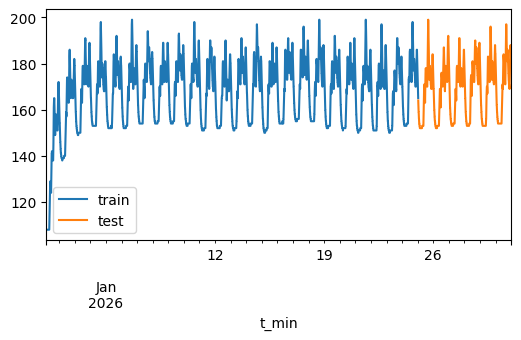

In [24]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3))
y_train.plot(ax=ax, label='train')
y_test.plot(ax=ax, label='test')
ax.legend()

In [25]:
FORECAST_STEPS = 6   # 30-minutos horizonte
SEED = 123
 
forecaster = ForecasterDirect(
    estimator=XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
    ),
    steps=FORECAST_STEPS,
    lags=6,                   # ultimos 30 min de glucemias
    n_jobs="auto",             
)
forecaster.fit(y=y_train,exog=x_train)
forecaster

================ 
ForecasterDirect 
================ 
Estimator: XGBRegressor 
Lags: [1 2 3 4 5 6] 
Window features: None 
Window size: 6 
Maximum steps to predict: 6 
Series name: gluc_mg 
Exogenous included: True 
Exogenous names: 
    meal_carb, snack_carb, bolus_insulin, basal_insulin, running_speed,
    meal_carb_-20m, meal_carb_-40m, meal_carb_-60m, meal_carb_-80m,
    meal_carb_-100m, meal_carb_-120m, meal_carb_-140m, meal_carb_-160m,
    meal_carb_-180m, meal_carb_-200m, meal_carb_-220m, meal_carb_-240m,
    snack_carb_-20m, snack_carb_-40m, snack_carb_-60m, snack_carb_-80m,
    snack_carb_-100m, snack_carb_-120m, snack_carb_-140m, snack_carb_-160m, ...,
    bolus_insulin_-20m, bolus_insulin_-40m, bolus_insulin_-60m,
    bolus_insulin_-80m, bolus_insulin_-100m, bolus_insulin_-120m,
    bolus_insulin_-140m, bolus_insulin_-160m, bolus_insulin_-180m,
    bolus_insulin_-200m, bolus_insulin_-220m, bolus_insulin_-240m,
    running_speed_-20m, running_speed_-40m, running_speed_-60m,
    running_speed_-80m, running_speed_-100m, running_speed_-120m,
    running_speed_-140m, running_speed_-160m, running_speed_-180m,
    running_speed_-200m, running_speed_-220m, running_speed_-240m, basal_-24h 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2026-01-01 04:00:00'), Timestamp('2026-01-25 00:45:00')] 
Training index type: DatetimeIndex 
Training index frequency: <5 * Minutes> 
Estimator parameters: 
    {'objective': 'reg:squarederror', 'base_score': None, 'booster': None,
    'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None,
    'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None,
    'enable_categorical': False, 'eval_metric': None, 'feature_types': None,
    'feature_weights': None, 'gamma': None, 'grow_policy': None,
    'importance_type': None, 'interaction_constraints': None, 'learning_rate':
    0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None,
    'max_delta_step': None, 'max_depth': 5, 'max_leaves': None,
    'min_child_weight': None, 'missing': nan, 'monotone_constraints': None,
    'multi_strategy': None, 'n_estimators': 200, 'n_jobs': None,
    'num_parallel_tree': None, 'random_state': 123, 'reg_alpha': None,
    'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None,
    'subsample': 0.8, 'tree_method': None, 'validate_parameters': None,
    'verbosity': None} 
fit_kwargs: {} 
Creation date: 2026-04-15 12:17:04 
Last fit date: 2026-04-15 12:17:09 
Skforecast version: 0.21.0 
Python version: 3.12.12 
Forecaster id: None

In [28]:
predictions = forecaster.predict(exog= x_test.loc[6914:,:])
predictions.head()

TypeError: cannot do slice indexing on DatetimeIndex with these indexers [6914] of type int

In [72]:
forecaster.get_feature_importances(step=3)


,feature,importance
0,lag_1,0.872017
22,snack_carb_-40m,0.021041
3,lag_4,0.018806
12,meal_carb_-80m,0.016574
13,meal_carb_-100m,0.014819
11,meal_carb_-60m,0.008609
10,meal_carb_-40m,0.006076
16,meal_carb_-160m,0.005703
17,meal_carb_-180m,0.005370
23,snack_carb_-60m,0.004508


### Estadíticas

In [9]:
from Funciones import estadisticas_rango

estadisticas_rango(datos[1]['p_2'])


{'TIR': [28.31], 'TAR': [71.69], 'TBR': [0.0]}

In [10]:
estadisticas = pd.DataFrame(columns=['Simulacion','Paciente', 'TBR', 'TIR', 'TAR'])
# display(est)
for simu in range(1,7):
    for p in range(20):
        est_l = estadisticas_rango(datos[simu][f'p_{p}'])
        est_l.update({'Simulacion': [simu], 'Paciente': [p]})
        df_l = pd.DataFrame(est_l)
        estadisticas = pd.concat([estadisticas, df_l])
estadisticas.head(20)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15204\966208211.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  estadisticas = pd.concat([estadisticas, df_l])


,Simulacion,Paciente,TBR,TIR,TAR
0,1,0,0.0,83.94,16.06
0,1,1,0.0,98.83,1.17
0,1,2,0.0,28.31,71.69
0,1,3,0.0,25.56,74.44
0,1,4,0.0,1.65,98.35
0,1,5,0.0,100.00,0.00
0,1,6,0.0,92.22,7.78
0,1,7,0.0,99.96,0.04
0,1,8,0.0,3.47,96.53
0,1,9,0.0,1.95,98.05


In [13]:
for i in range(20):
    display(estadisticas[estadisticas['Paciente']==i])

,Simulacion,Paciente,TBR,TIR,TAR
0,1,0,0.0,83.94,16.06
0,2,0,0.0,82.77,17.23
0,3,0,0.0,95.70,4.30
0,4,0,0.0,79.35,20.65
0,5,0,0.0,84.66,15.34
0,6,0,0.0,87.15,12.85


,Simulacion,Paciente,TBR,TIR,TAR
0,1,1,0.0,98.83,1.17
0,2,1,0.0,98.41,1.59
0,3,1,0.0,99.57,0.43
0,4,1,0.0,93.62,6.38
0,5,1,0.0,98.16,1.84
0,6,1,0.0,98.08,1.92


,Simulacion,Paciente,TBR,TIR,TAR
0,1,2,0.0,28.31,71.69
0,2,2,0.0,29.02,70.98
0,3,2,0.0,29.50,70.50
0,4,2,0.0,30.22,69.78
0,5,2,0.0,27.14,72.86
0,6,2,0.0,29.57,70.43


,Simulacion,Paciente,TBR,TIR,TAR
0,1,3,0.0,25.56,74.44
0,2,3,0.0,22.05,77.95
0,3,3,0.0,30.52,69.48
0,4,3,0.0,14.76,85.24
0,5,3,0.0,17.80,82.20
0,6,3,0.0,24.45,75.55


,Simulacion,Paciente,TBR,TIR,TAR
0,1,4,0.0,1.65,98.35
0,2,4,0.0,2.25,97.75
0,3,4,0.0,2.19,97.81
0,4,4,0.0,6.81,93.19
0,5,4,0.0,4.71,95.29
0,6,4,0.0,4.96,95.04


...

,Simulacion,Paciente,TBR,TIR,TAR
0,1,15,0.0,2.04,97.96
0,2,15,0.0,2.55,97.45
0,3,15,0.0,2.45,97.55
0,4,15,0.0,3.63,96.37
0,5,15,0.0,3.16,96.84
0,6,15,0.0,3.80,96.20


,Simulacion,Paciente,TBR,TIR,TAR
0,1,16,0.0,11.28,88.72
0,2,16,0.0,11.60,88.40
0,3,16,0.0,16.61,83.39
0,4,16,0.0,11.81,88.19
0,5,16,0.0,10.98,89.02
0,6,16,0.0,13.31,86.69


,Simulacion,Paciente,TBR,TIR,TAR
0,1,17,0.0,75.79,24.21
0,2,17,0.0,73.70,26.30
0,3,17,0.0,77.36,22.64
0,4,17,0.0,68.87,31.13
0,5,17,0.0,71.57,28.43
0,6,17,0.0,74.62,25.38


,Simulacion,Paciente,TBR,TIR,TAR
0,1,18,0.0,92.35,7.65
0,2,18,0.0,91.09,8.91
0,3,18,0.0,92.83,7.17
0,4,18,0.0,90.19,9.81
0,5,18,0.0,89.29,10.71
0,6,18,0.0,89.77,10.23


,Simulacion,Paciente,TBR,TIR,TAR
0,1,19,0.0,22.86,77.14
0,2,19,0.0,22.88,77.12
0,3,19,0.0,39.56,60.44
0,4,19,0.0,25.83,74.17
0,5,19,0.0,24.02,75.98
0,6,19,0.0,35.03,64.97
